# 02 - Entrenamiento de modelos

Notebook de semana 3 para fine-tuning de modelos de deteccion sobre CarDD COCO. Permite correr tandas parciales de experimentos y guardar resultados acumulables.

## 1. Imports y configuración

In [1]:
from pathlib import Path
import random
import shutil
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from prod.detection_dataset import (
    CarDamageDetectionDataset,
    ComposeDetection,
    RandomHorizontalFlipDetection,
    ToTensorDetection,
    collate_fn,
)
from prod.detection_models import (
    build_optimizer,
    create_model_from_config,
    describe_parameter_counts,
)
from prod.detection_training import run_detection_experiment
from utils import (
    append_jsonl_record,
    export_results_comparison_html,
    load_experiment_runs,
    make_experiment_run_record,
)


In [2]:
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATA_DIR = PROJECT_ROOT / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "dev" / "experiments"
RUNS_MANIFEST_PATH = PROJECT_ROOT / "dev" / "runs_manifest.jsonl"
RESULTS_HTML_PATH = PROJECT_ROOT / "dev" / "results_comparison.html"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("DATA_DIR:", DATA_DIR)
print("RUNS_MANIFEST_PATH:", RUNS_MANIFEST_PATH)
print("RESULTS_HTML_PATH:", RESULTS_HTML_PATH)


Device: cuda
DATA_DIR: C:\Users\Usuario\Documents\Proyecto Final Joaco\data
RUNS_MANIFEST_PATH: C:\Users\Usuario\Documents\Proyecto Final Joaco\dev\runs_manifest.jsonl


## 2. Verificación del dataset local

Este notebook requiere las imágenes reales del dataset en `train2017`, `val2017` y `test2017`.

In [3]:
required_dirs = [
    DATA_DIR / "CarDD_release" / "CarDD_COCO" / "train2017",
    DATA_DIR / "CarDD_release" / "CarDD_COCO" / "val2017",
    DATA_DIR / "CarDD_release" / "CarDD_COCO" / "test2017",
]
missing_dirs = [path for path in required_dirs if not path.exists()]
if missing_dirs:
    raise FileNotFoundError(
        "Faltan las carpetas de imagenes necesarias para entrenar:\n" + "\n".join(str(path) for path in missing_dirs)
    )

print("Dataset listo para entrenamiento.")


Dataset listo para entrenamiento.


## 3. Datasets y DataLoaders

In [4]:
BATCH_SIZE = 5
NUM_WORKERS = 0
BASE_MODEL_NAME = "fasterrcnn"

train_transform = ComposeDetection([
    ToTensorDetection(),
    RandomHorizontalFlipDetection(p=0.5),
])

eval_transform = ComposeDetection([
    ToTensorDetection(),
])

train_dataset = CarDamageDetectionDataset(
    data_dir=DATA_DIR,
    split="train",
    transform=train_transform,
    model_name=BASE_MODEL_NAME,
    resize=False,
    image_size=None,
)

val_dataset = CarDamageDetectionDataset(
    data_dir=DATA_DIR,
    split="val",
    transform=eval_transform,
    model_name=BASE_MODEL_NAME,
    resize=False,
    image_size=None,
)

test_dataset = CarDamageDetectionDataset(
    data_dir=DATA_DIR,
    split="test",
    transform=eval_transform,
    model_name=BASE_MODEL_NAME,
    resize=False,
    image_size=None,
)

NUM_CLASSES = len(train_dataset.class_to_idx)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
)

print("Clases:", NUM_CLASSES)
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))


Clases: 7
Train samples: 2816
Val samples: 810
Test samples: 374


## 4. Experimentos disponibles

Se comparan configuraciones de FCOS, RetinaNet y Faster R-CNN. La celda siguiente permite elegir una tanda parcial por indices.

In [ ]:
EXPERIMENTS = [
    {
        "name": "fcos_partial_backbone_fixed_size",
        "model_name": "fcos",
        "num_classes": NUM_CLASSES,
        "trainable_backbone_layers": 2,
        "optimizer_name": "sgd",
        "lr": 0.002,
        "momentum": 0.9,
        "weight_decay": 0.0005,
        "num_epochs": 5,
        "resize": True,
        "image_size": (640, 640),
    },
    {
        "name": "retinanet_partial_backbone_fixed_size",
        "model_name": "retinanet",
        "num_classes": NUM_CLASSES,
        "trainable_backbone_layers": 2,
        "optimizer_name": "sgd",
        "lr": 0.002,
        "momentum": 0.9,
        "weight_decay": 0.0005,
        "num_epochs": 5,
        "resize": True,
        "image_size": (640, 640),
    },
{
        "name": "fcos_partial_backbone_fixed_size",
        "model_name": "fcos",
        "num_classes": NUM_CLASSES,
        "trainable_backbone_layers": 2,
        "optimizer_name": "adamw",
        "lr": 0.002,
        "momentum": 0.9,
        "weight_decay": 0.0005,
        "num_epochs": 5,
        "resize": True,
        "image_size": (640, 640),
    },
    {
        "name": "retinanet_partial_backbone_fixed_size",
        "model_name": "retinanet",
        "num_classes": NUM_CLASSES,
        "trainable_backbone_layers": 2,
        "optimizer_name": "adamw",
        "lr": 0.002,
        "momentum": 0.9,
        "weight_decay": 0.0005,
        "num_epochs": 5,
        "resize": True,
        "image_size": (640, 640),
    },
    {
        "name": "fasterrcnn_head_only",
        "model_name": "fasterrcnn",
        "num_classes": NUM_CLASSES,
        "trainable_backbone_layers": 0,
        "optimizer_name": "sgd",
        "lr": 0.005,
        "momentum": 0.9,
        "weight_decay": 0.0005,
        "num_epochs": 5,
        "resize": False,
        "image_size": None,
    },
    {
        "name": "fasterrcnn_partial_backbone",
        "model_name": "fasterrcnn",
        "num_classes": NUM_CLASSES,
        "trainable_backbone_layers": 2,
        "optimizer_name": "sgd",
        "lr": 0.003,
        "momentum": 0.9,
        "weight_decay": 0.0005,
        "num_epochs": 5,
        "resize": False,
        "image_size": None,
    },
    {
        "name": "fasterrcnn_full_backbone_fixed_size",
        "model_name": "fasterrcnn",
        "num_classes": NUM_CLASSES,
        "trainable_backbone_layers": 5,
        "optimizer_name": "sgd",
        "lr": 0.001,
        "momentum": 0.9,
        "weight_decay": 0.0005,
        "num_epochs": 5,
        "resize": True,
        "image_size": (640, 640),
    },
    {
        "name": "fasterrcnn_mobilenet_v3_large_partial_backbone",
        "model_name": "fasterrcnn_mobilenet_v3_large_fpn",
        "num_classes": NUM_CLASSES,
        "trainable_backbone_layers": 2,
        "optimizer_name": "sgd",
        "lr": 0.002,
        "momentum": 0.9,
        "weight_decay": 0.0005,
        "num_epochs": 10,
        "resize": False,
        "image_size": None,
    },
    {
        "name": "fasterrcnn_mobilenet_v3_large_320_partial_backbone",
        "model_name": "fasterrcnn_mobilenet_v3_large_320_fpn",
        "num_classes": NUM_CLASSES,
        "trainable_backbone_layers": 2,
        "optimizer_name": "sgd",
        "lr": 0.002,
        "momentum": 0.9,
        "weight_decay": 0.0005,
        "num_epochs": 10,
        "resize": False,
        "image_size": None,
    },
]

pd.DataFrame(EXPERIMENTS)[[
    "name",
    "model_name",
    "trainable_backbone_layers",
    "lr",
    "num_epochs",
    "resize",
    "image_size",
]]


,name,model_name,trainable_backbone_layers,lr,num_epochs,resize,image_size
0,fcos_partial_backbone_fixed_size,fcos,2,0.002,5,True,"(640, 640)"
1,retinanet_partial_backbone_fixed_size,retinanet,2,0.002,5,True,"(640, 640)"
2,fcos_partial_backbone_fixed_size,fcos,2,0.002,5,True,"(640, 640)"
3,retinanet_partial_backbone_fixed_size,retinanet,2,0.002,5,True,"(640, 640)"
4,fasterrcnn_head_only,fasterrcnn,0,0.005,5,False,None
5,fasterrcnn_partial_backbone,fasterrcnn,2,0.003,5,False,None
6,fasterrcnn_full_backbone_fixed_size,fasterrcnn,5,0.001,5,True,"(640, 640)"
7,fasterrcnn_mobilenet_v3_large_partial_backbone,fasterrcnn_mobilenet_v3_large_fpn,2,0.002,5,False,None
8,fasterrcnn_mobilenet_v3_large_320_partial_back...,fasterrcnn_mobilenet_v3_large_320_fpn,2,0.002,5,False,None


In [ ]:
SELECTED_EXPERIMENT_INDICES = [7,8]
SELECTED_EXPERIMENTS = [EXPERIMENTS[i] for i in SELECTED_EXPERIMENT_INDICES]

pd.DataFrame(SELECTED_EXPERIMENTS)[[
    "name",
    "model_name",
    "trainable_backbone_layers",
    "lr",
    "num_epochs",
    "resize",
    "image_size",
]]


,name,model_name,trainable_backbone_layers,lr,num_epochs,resize,image_size
0,fasterrcnn_mobilenet_v3_large_320_partial_back...,fasterrcnn_mobilenet_v3_large_320_fpn,2,0.002,5,False,None


## 5. Helpers de entrenamiento

In [7]:
def build_dataloaders_for_experiment(experiment):
    train_dataset = CarDamageDetectionDataset(
        data_dir=DATA_DIR,
        split="train",
        transform=train_transform,
        model_name=experiment["model_name"],
        resize=experiment["resize"],
        image_size=experiment["image_size"],
    )
    val_dataset = CarDamageDetectionDataset(
        data_dir=DATA_DIR,
        split="val",
        transform=eval_transform,
        model_name=experiment["model_name"],
        resize=experiment["resize"],
        image_size=experiment["image_size"],
    )
    test_dataset = CarDamageDetectionDataset(
        data_dir=DATA_DIR,
        split="test",
        transform=eval_transform,
        model_name=experiment["model_name"],
        resize=experiment["resize"],
        image_size=experiment["image_size"],
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        collate_fn=collate_fn,
    )
    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        collate_fn=collate_fn,
    )
    test_loader = torch.utils.data.DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        collate_fn=collate_fn,
    )

    return train_loader, val_loader, test_loader


def plot_history(history, title):
    history_df = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    axes[0].set_title(f"{title} - Loss")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["map"], label="mAP@50:95")
    axes[1].plot(history_df["epoch"], history_df["map_50"], label="mAP@50")
    axes[1].set_title(f"{title} - mAP")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


## 6. Ejecucion de la tanda seleccionada

Cada experimento terminado se agrega como una linea JSON en `dev/runs_manifest.jsonl`. Si repetis un experimento, queda guardado como otra corrida historica.


===== fasterrcnn_mobilenet_v3_large_320_partial_backbone =====
{'trainable_parameters': 18174518, 'frozen_parameters': 781336, 'total_parameters': 18955854}
[fasterrcnn_mobilenet_v3_large_320_partial_backbone] Starting training for 5 epoch(s) at 2026-06-12T14:54:10
[fasterrcnn_mobilenet_v3_large_320_partial_backbone] Epoch 1/5 started at 2026-06-12T14:54:10


Train Epoch 1:   0%|          | 0/564 [00:00<?, ?it/s]

Validation Loss:   0%|          | 0/162 [00:00<?, ?it/s]

[fasterrcnn_mobilenet_v3_large_320_partial_backbone] Epoch 1/5 - duration_s=115.31 - train_loss=0.6333 - val_loss=0.6014 - map=0.2925 - map_50=0.4863 - lr=0.002000
[fasterrcnn_mobilenet_v3_large_320_partial_backbone] New best checkpoint at epoch 1 with map=0.2925
[fasterrcnn_mobilenet_v3_large_320_partial_backbone] Epoch 2/5 started at 2026-06-12T14:56:05


Train Epoch 2:   0%|          | 0/564 [00:00<?, ?it/s]

...

Validation Loss:   0%|          | 0/162 [00:00<?, ?it/s]

[fasterrcnn_mobilenet_v3_large_320_partial_backbone] Epoch 4/5 - duration_s=109.26 - train_loss=0.5245 - val_loss=0.6064 - map=0.3594 - map_50=0.5575 - lr=0.002000
[fasterrcnn_mobilenet_v3_large_320_partial_backbone] Epoch 5/5 started at 2026-06-12T15:01:40


Train Epoch 5:   0%|          | 0/564 [00:00<?, ?it/s]

Validation Loss:   0%|          | 0/162 [00:00<?, ?it/s]

[fasterrcnn_mobilenet_v3_large_320_partial_backbone] Epoch 5/5 - duration_s=107.12 - train_loss=0.5239 - val_loss=0.5694 - map=0.3889 - map_50=0.5715 - lr=0.002000
[fasterrcnn_mobilenet_v3_large_320_partial_backbone] New best checkpoint at epoch 5 with map=0.3889
[fasterrcnn_mobilenet_v3_large_320_partial_backbone] Training finished - duration_s=557.25 - best_epoch=5 - best_map=0.3889
Corrida guardada en manifest: C:\Users\Usuario\Documents\Proyecto Final Joaco\dev\runs_manifest.jsonl


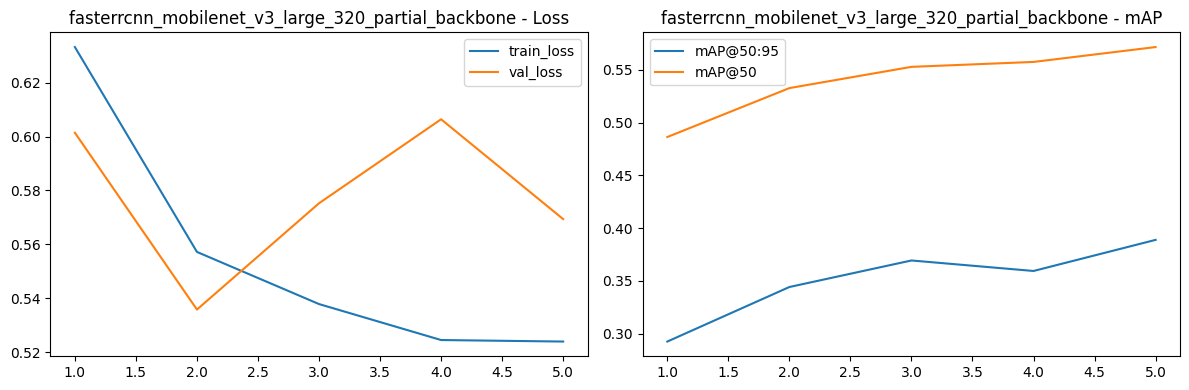

In [8]:
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
experiment_summaries = []
experiment_runs = {}

for experiment in SELECTED_EXPERIMENTS:
    print(f"\n===== {experiment['name']} =====")

    train_loader_exp, val_loader_exp, test_loader_exp = build_dataloaders_for_experiment(experiment)
    model = create_model_from_config(experiment)
    optimizer = build_optimizer(
        model,
        optimizer_name=experiment["optimizer_name"],
        lr=experiment["lr"],
        momentum=experiment["momentum"],
        weight_decay=experiment["weight_decay"],
    )

    parameter_counts = describe_parameter_counts(model)
    print(parameter_counts)

    run_result = run_detection_experiment(
        model=model,
        train_loader=train_loader_exp,
        val_loader=val_loader_exp,
        optimizer=optimizer,
        device=DEVICE,
        num_epochs=experiment["num_epochs"],
        experiment_name=experiment["name"],
        config=experiment,
        output_dir=ARTIFACTS_DIR,
        class_metrics=True,
    )

    experiment_runs[experiment["name"]] = {
        "config": experiment,
        "run_result": run_result,
        "test_loader": test_loader_exp,
    }

    history_df = pd.DataFrame(run_result["history"])
    best_row = history_df.loc[history_df["map"].idxmax()].to_dict()
    run_record = make_experiment_run_record(experiment, run_result, best_row)
    if run_record["checkpoint_path"] is not None:
        archived_checkpoint_path = ARTIFACTS_DIR / f"{run_record['run_id']}_best.pth"
        shutil.copy2(run_record["checkpoint_path"], archived_checkpoint_path)
        run_record["checkpoint_path"] = str(archived_checkpoint_path)
    append_jsonl_record(RUNS_MANIFEST_PATH, run_record)
    experiment_summaries.append(run_record)
    print(f"Corrida guardada en manifest: {RUNS_MANIFEST_PATH}")

    plot_history(run_result["history"], experiment["name"])


## 7. Comparacion acumulada de resultados

Esta tabla lee todas las corridas guardadas en `runs_manifest.jsonl`, incluyendo tandas anteriores.

In [9]:
all_runs_df = load_experiment_runs(RUNS_MANIFEST_PATH)
if all_runs_df.empty:
    raise ValueError(f"No hay corridas guardadas en {RUNS_MANIFEST_PATH}")

results_df = all_runs_df.sort_values(by="best_map", ascending=False).reset_index(drop=True)
results_html_path = export_results_comparison_html(
    results_df.drop(columns=["config", "history"], errors="ignore"),
    RESULTS_HTML_PATH,
)
print(f"Tabla acumulada exportada a HTML en: {results_html_path}")
results_df.drop(columns=["config", "history"], errors="ignore")


Tabla acumulada exportada a HTML en: C:\Users\Usuario\Documents\Proyecto Final Joaco\dev\results_comparison.html


,run_id,created_at,name,best_epoch,best_map,best_map_50,best_map_75,best_val_loss,checkpoint_path,training_start_time,training_end_time,training_duration_seconds,optimizer_name,trainable_backbone_layers
0,20260612_121844_fcos_partial_backbone_fixed_size,2026-06-12T12:18:44,fcos_partial_backbone_fixed_size,5,0.438589,0.576652,0.456578,1.251634,C:\Users\Usuario\Documents\Proyecto Final Joac...,2026-06-12T11:44:50,2026-06-12T12:18:44,2034.143480,sgd,2
1,20260612_144006_fasterrcnn_mobilenet_v3_large_...,2026-06-12T14:40:06,fasterrcnn_mobilenet_v3_large_partial_backbone,5,0.437546,0.624298,0.467888,0.626575,C:\Users\Usuario\Documents\Proyecto Final Joac...,2026-06-12T14:25:22,2026-06-12T14:40:06,884.429377,sgd,2
2,20260612_150327_fasterrcnn_mobilenet_v3_large_...,2026-06-12T15:03:27,fasterrcnn_mobilenet_v3_large_320_partial_back...,5,0.388873,0.571542,0.417644,0.569379,C:\Users\Usuario\Documents\Proyecto Final Joac...,2026-06-12T14:54:10,2026-06-12T15:03:27,557.253054,sgd,2
3,20260612_124444_retinanet_partial_backbone_fix...,2026-06-12T12:44:44,retinanet_partial_backbone_fixed_size,5,0.370456,0.474679,0.386296,0.682721,C:\Users\Usuario\Documents\Proyecto Final Joac...,2026-06-12T12:18:46,2026-06-12T12:44:44,1557.840156,sgd,2
4,20260612_141634_fasterrcnn_mobilenet_v3_large_...,2026-06-12T14:16:34,fasterrcnn_mobilenet_v3_large_320_partial_back...,5,0.330813,0.508401,0.373067,0.468213,C:\Users\Usuario\Documents\Proyecto Final Joac...,2026-06-12T14:07:14,2026-06-12T14:16:34,560.552993,sgd,0
5,20260612_131843_fcos_partial_backbone_fixed_size,2026-06-12T13:18:43,fcos_partial_backbone_fixed_size,3,0.010527,0.041907,0.002816,1.783011,C:\Users\Usuario\Documents\Proyecto Final Joac...,2026-06-12T12:44:45,2026-06-12T13:18:43,2037.473019,adamw,2
6,20260612_134443_retinanet_partial_backbone_fix...,2026-06-12T13:44:43,retinanet_partial_backbone_fixed_size,1,0.000000,0.000000,0.000000,1.673423,C:\Users\Usuario\Documents\Proyecto Final Joac...,2026-06-12T13:18:45,2026-06-12T13:44:43,1558.472093,adamw,2
